In [46]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import precision_recall_curve, roc_curve, auc


DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

playlists = ["1A"]

training_names = { # Model -> training name
    "Transformer": "Pi_Class_v3_20260303_082729",
    "OmniLearned_Small": "Train_CC1orNPi_v3_1A_20260303_170126",
    "OmniLearned_Small_PT": "Train_CC1orNPi_v3_PT_S_1A_20260303_170241"
}


In [47]:
def eval_commands(training_names):
    for key in training_names.keys():
        for _ in playlists:
            if "omni" in key.lower():
                print(f"omnilearned evaluate -i {CKPT_DIR}/{training_names[key]} --num-workers 2 --batch 100")
            else:
                print(f"python -m src.scripts.eval --checkpoint {CKPT_DIR}/{training_names[key]} --batch_size 1024 --dataset_name minerva_1A --no_amp ")

eval_commands(training_names)


python -m src.scripts.eval --checkpoint /global/cfs/cdirs/m3246/gregork/checkpoints/Pi_Class_v3_20260303_082729 --batch_size 1024 --dataset_name minerva_1A --no_amp 
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_v3_1A_20260303_170126 --num-workers 2 --batch 100
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_v3_PT_S_1A_20260303_170241 --num-workers 2 --batch 100


In [48]:
results = {}
configs = {}
baselines = {}
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    # File looks like this: $CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
    results[key] = {}
    configs[key] = {}
    for playlist in playlists:
        path1 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_{training_names[key]}_minerva_{playlist}_0.npz"
        path2 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
        if path1.exists():
            results[key][playlist] = dict(np.load(path1))
        elif path2.exists():
            results[key][playlist] = dict(np.load(path2))
        else:
            raise ValueError(f"No results found for {training_names[key]} on playlist {playlist} - {path1} and {path2} do not exist")
        settings_path = CKPT_DIR / training_names[key] / "settings.json"
        if settings_path.exists():
            configs[key][playlist] = json.load(open(settings_path, "rb"))
        else:
            print(f"No settings found for {training_names[key]} on playlist {playlist}")
            configs[key][playlist] = {}

# Softmax the transformer predictions
results["Transformer"]["1A"]["prediction"] = np.exp(results["Transformer"]["1A"]["prediction"]) / np.sum(np.exp(results["Transformer"]["1A"]["prediction"]), axis=1, keepdims=True)


No settings found for Pi_Class_v3_20260303_082729 on playlist 1A


In [49]:
data_paths = {}
for key in training_names.keys():
    data_paths[key] = {}
    data_paths[key] = {}
    for playlist in playlists:
        data_paths[key][playlist] = {}
        #models[key][model][playlist]["settings"] = configs[key][model][playlist]
        model_path = CKPT_DIR / training_names[key] / "best_model.pt"
        if os.path.exists(model_path):
            data_paths[key][playlist] = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))["args"]["data_path"]
        else:
            print(f"No best model found for {training_names[key]} on playlist {playlist}")
            del data_paths[key][playlist]

No best model found for Train_CC1orNPi_v3_1A_20260303_170126 on playlist 1A
No best model found for Train_CC1orNPi_v3_PT_S_1A_20260303_170241 on playlist 1A


In [50]:
default_data_dir = Path(data_paths["Transformer"][playlists[0]])
split_idx = pickle.load(open(default_data_dir / "result.pkl", "rb"))

baselines = {}
for playlist in playlists:
    test_idx = split_idx[playlist]["test_idx"]
    baseline_file = f"{playlist}_enu_baselines.npz"
    loaded = False
    for subdir in ["baselines2", "baselines1", "baselines"]:
        candidate = default_data_dir / subdir / baseline_file
        if candidate.exists():
            baselines[playlist] = dict(np.load(candidate))
            print(f"[{playlist}] Loaded baselines from {candidate}")
            loaded = True
            break
    if not loaded:
        print(f"[{playlist}] WARNING: No baselines found in {default_data_dir}")

[1A] Loaded baselines from /global/cfs/cdirs/m3246/gregork/Minerva/20260227_100Blobs_v1_split/baselines2/1A_enu_baselines.npz


In [51]:
truth_labels = {}
default_model = "Transformer"
for key in data_paths[default_model].keys():
    truth_labels[key] = torch.load(open(Path(data_paths[default_model][key]) /  key / "test" / "0.pb", "rb"), weights_only=False, map_location=torch.device("cpu"))["truth_labels"]

In [73]:
def get_CC1orNPi_labels(file_truth_labels):
    # Generate labels for CC 1pi or n pions, according to signal definition in Eberly et al. 2015, on the fly
    is_cc = file_truth_labels[:, 3] == 1
    n_pi_plus = file_truth_labels[:, 5]
    n_pi_minus = file_truth_labels[:, 6]
    labels = torch.zeros(len(file_truth_labels), dtype=torch.long)
    one_pi_plus = n_pi_plus == 1
    one_pi_minus = n_pi_minus == 1
    multi_pions = (n_pi_plus + n_pi_minus) > 1
    labels[is_cc & one_pi_plus & ~one_pi_minus] = 0 # CC 1pi+
    labels[is_cc & one_pi_minus & ~one_pi_plus] = 1 # CC 1pi-
    labels[is_cc & multi_pions] = 2 # CC N Pi +-
    labels[~is_cc] = 3 # Not CC
    labels[is_cc & ((n_pi_plus + n_pi_minus) == 0)] = 4 # CC other
    return labels # Labels: 0=CC 1pi+, 1=CC 1pi-, 2=CC N charged pions-, 3=OTHER

def get_Pi_labels_v2(file_truth_labels):
    # label0 = CC, 1 charged pion, the rest whatever
    # label1 = CC, N >1charged pion, the rest whatever
    # label2 = CC, 1 pi0, no charged pions
    # label3 = CC, all others
    # label4 = NC
    is_cc = file_truth_labels[:, 3] == 1
    n_pi_plus = file_truth_labels[:, 5]
    n_pi_minus = file_truth_labels[:, 6]
    n_pi_zero = file_truth_labels[:, 10]
    labels = torch.ones(len(file_truth_labels), dtype=torch.long)*4 # 4 is the label for other
    labels[is_cc & (n_pi_plus == 1) & (n_pi_minus == 0)] = 0
    labels[is_cc & ((n_pi_plus + n_pi_minus) > 1)] = 1
    labels[is_cc & ((n_pi_plus + n_pi_minus) == 0)] = 3
    labels[is_cc & (n_pi_zero == 1) & (n_pi_plus == 0) & (n_pi_minus == 0)] = 2
    return labels
truth_labels_class = get_Pi_labels_v2(truth_labels["1A"])

In [74]:
class_labels, val_counts = torch.unique(truth_labels["1A"][:, 3], return_counts=True)
val_counts_relative = val_counts.numpy() / len(truth_labels["1A"]) * 100

In [75]:
class_idx, class_counts = torch.unique(truth_labels_class, return_counts=True) # print percentages
class_counts_all = class_counts.sum().item()
class_counts_percentages = class_counts.numpy() / class_counts_all * 100
print(f"Class fractions [%]: {class_counts_percentages}")
dataset_to_plot = "1A"

Class fractions [%]: [30.54664156 24.63314479  8.24744981 24.31750392 12.25525991]


In [76]:
# Get idx that have atleast one nonzero
idx = (truth_labels["1A"][:, -4:] != 0).any(axis=1)
truth_labels_class = get_CC1orNPi_labels(truth_labels["1A"][idx])

In [77]:
model_to_plot = "Transformer"
datasets = results[model_to_plot].keys()
labels_event_type = ["CC1pi+/-", "CCNpi", "CC1pi0", "Other-CC", "Other-NC"]

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


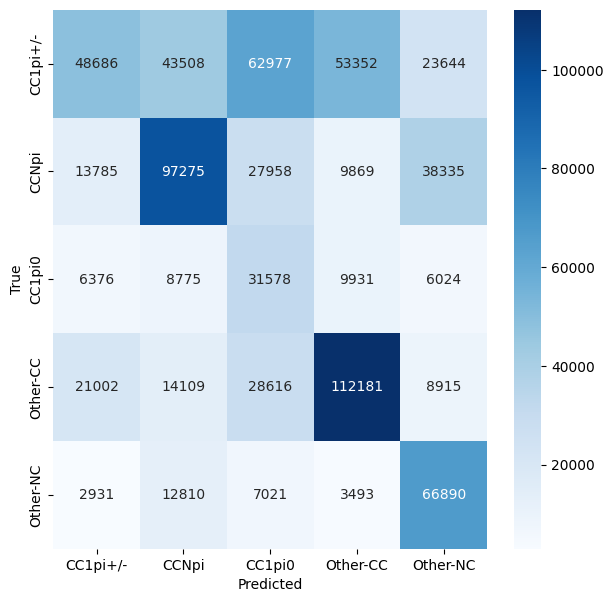

In [79]:
# 12 datasets: Make a 3 x 4 grid of confusion matrices
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
plot_confusion_matrix_on_ax(ax, results[model_to_plot][dataset_to_plot]["pid"], results[model_to_plot][dataset_to_plot]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


In [80]:
def get_signal_probabilities(model_to_plot, dataset_to_plot="1A", signal_classes=None):
    remap = {}
    # set signal classes to 1 and the rest to 0.
    for cls in signal_classes:
        remap[cls] = 1
    y_true = np.array([remap.get(x, 0) for x in results[model_to_plot][dataset_to_plot]["pid"]])
    print("Fraction of signal:", y_true.mean())
    all_logits = results[model_to_plot][dataset_to_plot]["prediction"]
    all_probs = all_logits
    y_pred = sum([all_probs[:, i] for i in signal_classes])
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    tpr, fpr, thresholds1 = roc_curve(y_true, y_pred)
    auprc = auc(recall, precision)
    auroc = auc(fpr, tpr)
    return {
        "prc": [precision, recall, thresholds, auprc],
        "roc": [tpr, fpr, thresholds1, auroc],
        "ytrue": y_true,
        "ypred": y_pred
    }

Fraction of signal: 0.305466415627578
Transformer: AUPRC: 0.471
Fraction of signal: 0.305466415627578
OmniLearned_Small: AUPRC: 0.472
Fraction of signal: 0.305466415627578
OmniLearned_Small_PT: AUPRC: 0.478


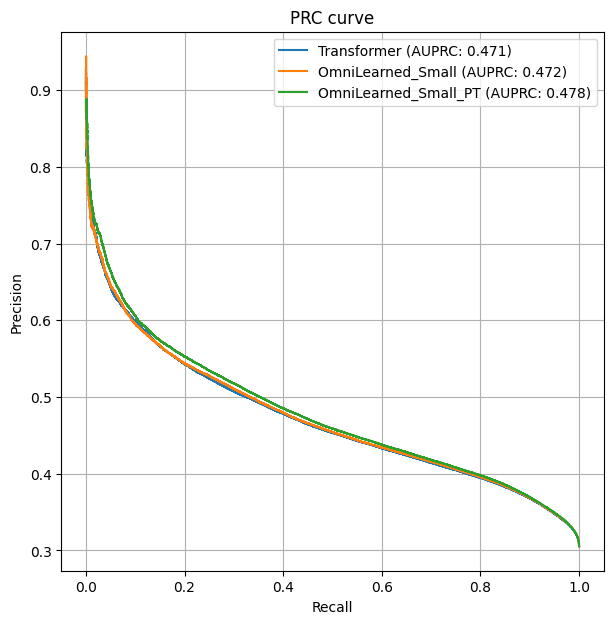

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
#fig_roc, ax_roc = plt.subplots(1, 1, figsize=(7, 7))

for model in results.keys():
    precision, recall, thresholds, auprc = get_signal_probabilities(model, "1A", [0])["prc"]
    # precision_recall_curve returns len(precision) == len(thresholds) + 1; drop sentinel
    precision = precision[:-1]
    recall = recall[:-1]
    # Remove thresholds < 0.01 and > 0.99
    mask = (thresholds >= 0) & (thresholds <= 0.8)
    precision = precision[mask]
    recall = recall[mask]
    thresholds = thresholds[mask]
    ax.plot(recall, precision, "-", label=model + f" (AUPRC: {auprc:.3f})")
    #ax_roc.plot(fpr, tpr, "-", label=model)
    # print auprc and auroc
    print(f"{model}: AUPRC: {auprc:.3f}")

ax.legend()
ax.grid()
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PRC curve")
fig.show()



In [126]:
test_idx = split_idx["1A"]["test_idx"]
pion_four_vector_MC = baselines["1A"]["pion_four_vectors"][test_idx] / 1000.0
pion_E_MC = pion_four_vector_MC[:, -1]
nonzero_mask = pion_E_MC > 0
pion_p_MC = np.linalg.norm(pion_four_vector_MC[:, 1:4], axis=1)
pion_theta_MC = np.arccos(pion_four_vector_MC[:, 2] / pion_p_MC)

/tmp/ipykernel_139804/863099244.py:6: RuntimeWarning: invalid value encountered in divide
  pion_theta_MC = np.arccos(pion_four_vector_MC[:, 2] / pion_p_MC)


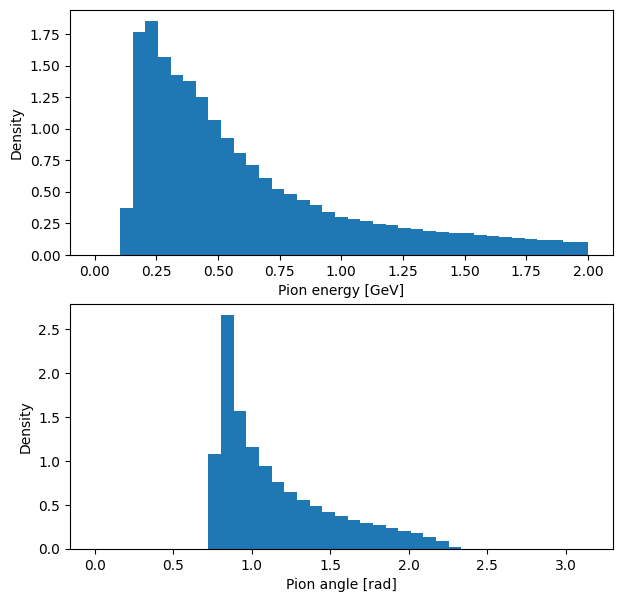

In [127]:
fig, ax = plt.subplots(2, 1, figsize=(7, 7))
ax[0].hist(pion_E_MC[nonzero_mask], bins=np.linspace(0, 2, 40), density=True)
ax[1].hist(pion_theta_MC, bins=np.linspace(0, np.pi, 40), density=True)
ax[0].set_xlabel("Pion energy [GeV]")
ax[1].set_xlabel("Pion angle [rad]")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Density")
fig.show()


In [128]:

ytrue = results[model_to_plot][dataset_to_plot]["pid"]
mask1 = (ytrue == 0) | (ytrue == 2)
nonzero_pion_mask = (pion_four_vector_MC[:, -1] > 0)


In [ ]:
pion_theta_MC_bins = np.array([0, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5])
pion_E_MC_bins = np.array([0, 0.5, 0.75, 1.0, 2.0])


threshold = 0.5
# Now, make a plot of pion energy (middle of bin) vs. efficiency for each threshold...
result = get_signal_probabilities(model, "1A", [0])
y_true = result["ytrue"]
probs = result["ypred"]

efficiency, signal_efficiency = {"E": [], "theta": []}, {"E": [], "theta": []}
thresholds = np.linspace(0.3, 0.8, 10)

for bin_idx in range(len(pion_E_MC_bins) - 1):
    mask_bin = (pion_E_MC > pion_E_MC_bins[bin_idx]) & (pion_E_MC <= pion_E_MC_bins[bin_idx + 1])
    N_GT_events_in_bin = (mask_bin & nonzero_pion_mask).sum().item()
    mask_selected_events = (probs > threshold)
    mask_selected_events_in_bin = mask_selected_events & mask_bin
    N_selected_events_in_bin = mask_selected_events_in_bin.sum().item()
    if N_GT_events_in_bin > 0:
        efficiency["E"].append(N_selected_events_in_bin / N_GT_events_in_bin)
    else:
        print("No GT events in bin", bin_idx)

# similar for theta bins
for bin_idx in range(len(pion_theta_MC_bins) - 1):
    mask_bin = (pion_theta_MC > pion_theta_MC_bins[bin_idx]) & (pion_theta_MC <= pion_theta_MC_bins[bin_idx + 1])
    N_GT_events_in_bin = (mask_bin & nonzero_pion_mask).sum().item()
    mask_selected_events = (probs > threshold)
    mask_selected_events_in_bin = mask_selected_events & mask_bin
    N_selected_events_in_bin = mask_selected_events_in_bin.sum().item()
    if N_GT_events_in_bin > 0:
        efficiency["theta"].append(N_selected_events_in_bin / N_GT_events_in_bin)
    else:
        print("No GT events in bin", bin_idx)


Fraction of signal: 0.305466415627578


{'E': [0.0631985903269074,
  0.03422518250921954,
  0.02543599641552354,
  0.01864709383058917],
 'theta': [0.028995632003038608,
  0.05261299435028249,
  0.057526294899781706,
  0.05341919432146647,
  0.06220872388333246,
  0.05410106984430721]}

Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092


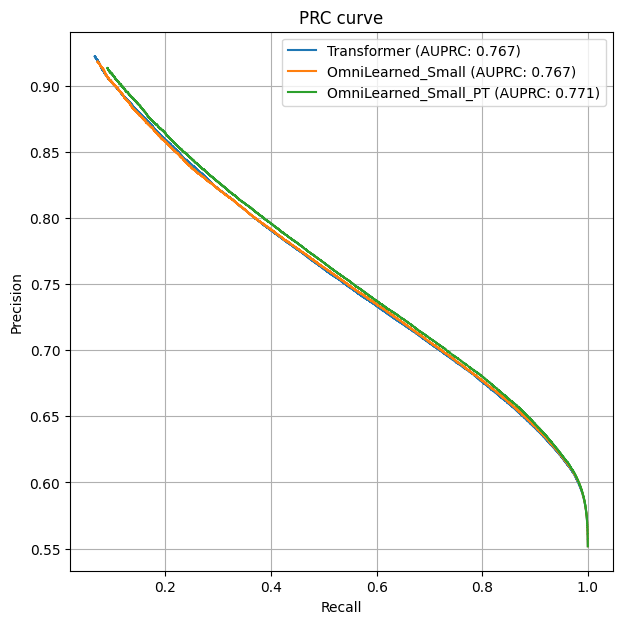

In [ ]:
# Plot PRC curve for this too
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model in results.keys():
    precision, recall, thresholds, auprc = get_signal_probabilities(model, "1A", [0, 1])["prc"]
    mask = (thresholds >= 0) & (thresholds <= 0.8)
    thresholds = thresholds[mask]
    precision = precision[:-1][mask]
    recall = recall[:-1][mask]
    ax.plot(recall, precision, "-", label=model + f" (AUPRC: {auprc:.3f})")
ax.legend()
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PRC curve")
ax.grid()
fig.show()